<a href="https://colab.research.google.com/github/peakodev/data_science/blob/main/home_04/Hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лінійна регресія: перенавчання і регуляризація

У цьому завданні ми на прикладах побачимо, як перенавчаються лінійні моделі, розберемо, чому так відбувається, і з'ясуємо, як діагностувати та контролювати перенавчання.

В усіх комірках, де вказаний коментар з інструкціями, потрібно написати код, який виконує ці інструкції. Решту комірок із кодом (без коментарів) треба просто виконати. Крім того, у завданні необхідно відповідати на запитання; відповіді потрібно вписувати після виділеного слова "__Відповідь:__".

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

Ми будемо працювати з датасетом __"bikes_rent.csv"__, у якому по днях записані календарна інформація та погодні умови, що характеризують автоматизовані пункти прокату велосипедів, а також кількість прокатів у цей день. Останнє ми будемо передбачати; таким чином, ми будемо розв'язувати завдання регресії.

### Ознайомлення з даними

## Завдання 1

Завантажте датасет за допомогою функції __pandas.read_csv__ у змінну __df__. Виведіть перші 5 рядків, щоб переконатися в коректному зчитуванні даних:

In [2]:
df = pd.read_csv("bikes_rent.csv")
df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,4.805490,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,7.443949,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,7.437060,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,4.800998,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,5.597810,1600


Для кожного дня прокату відомі такі ознаки:
* _season_: 1 — весна, 2 — літо, 3 — осінь, 4 — зима
* _yr_: 0 — 2011, 1 — 2012
* _mnth_: від 1 до 12
* _holiday_: 0 — немає свята, 1 — є свято
* _weekday_: від 0 до 6
* _workingday_: 0 — неробочий день, 1 — робочий день
* _weathersit_: оцінка сприятливості погоди від 1 (чистий, ясний день) до 4 (злива, туман)
* _temp_: температура в Цельсіях
* _atemp_: температура за відчуттями в Цельсіях
* _hum_: вологість
* _windspeed(mph)_: швидкість вітру в милях за годину
* _windspeed(ms)_: швидкість вітру в метрах за секунду
* _cnt_: кількість орендованих велосипедів (це цільова ознака, її ми будемо передбачати)

Отже, у нас є речові, бінарні та номінальні (порядкові) ознаки, і з усіма з них можна працювати як з речовими. З номінальними ознаками теж можна працювати як з речовими, тому що на них заданий порядок. Давайте подивимося на графіках, як цільова ознака залежить від решти.

Побудуйте графіки залежностей атрибутів від кількості поїздок. Іншими словами, вам потрібно побудувати 12 графіків. На кожному має бути зображена залежність чергового атрибута від змінної **cnt**.

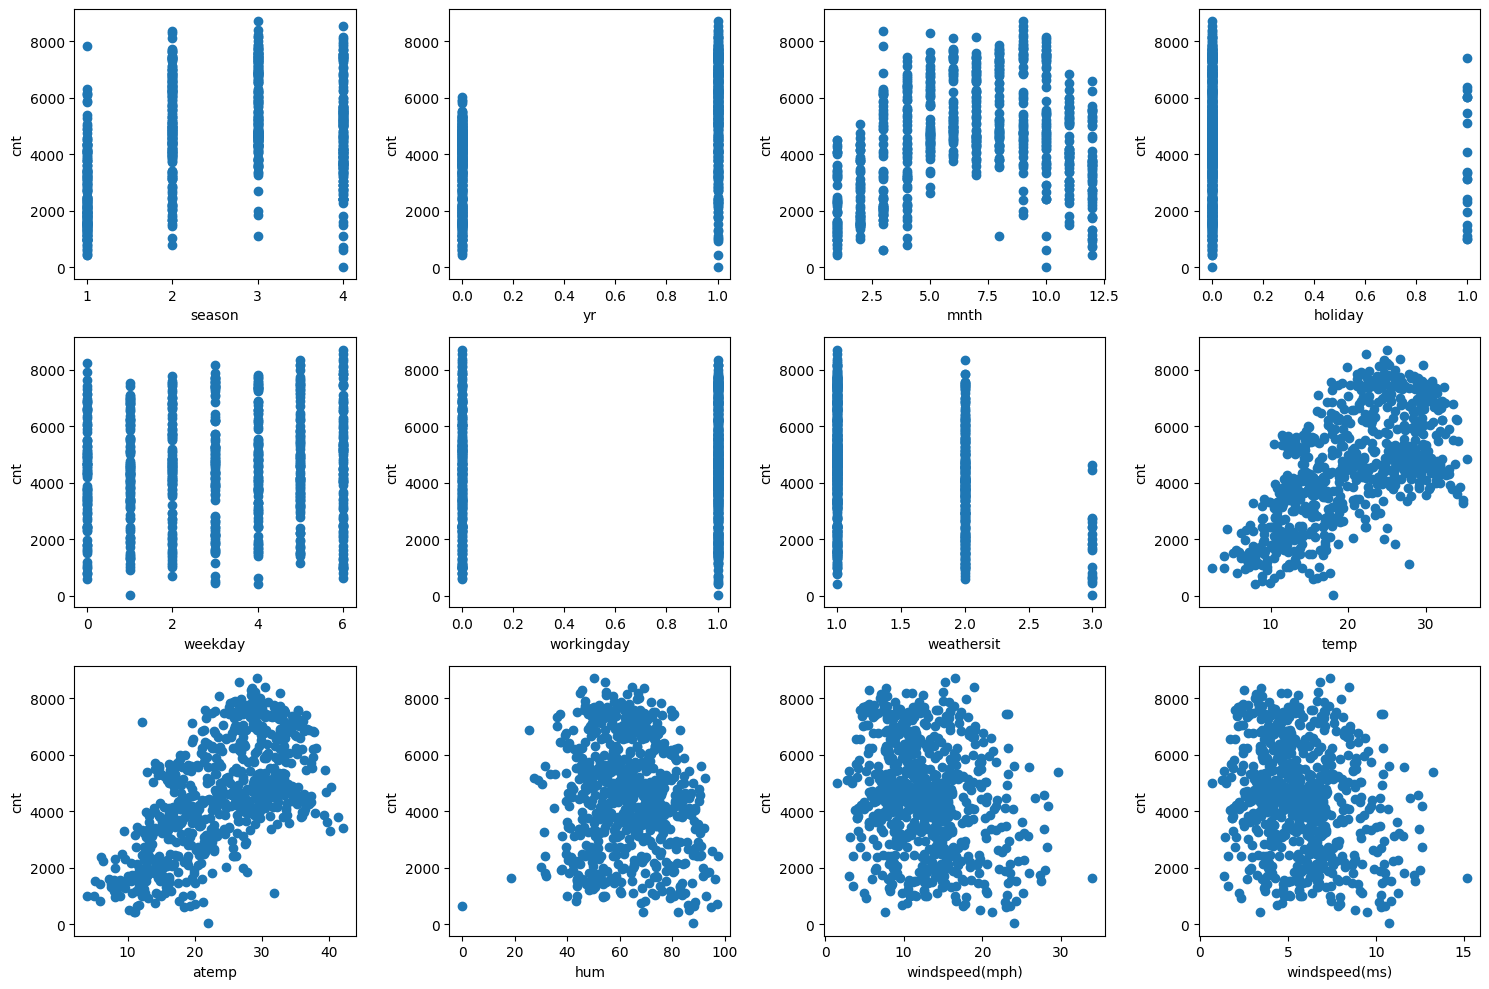

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(15, 10))
for idx, feature in enumerate(df.columns[:-1]):
    row, col = divmod(idx, 4)
    axes[row, col].scatter(df[feature], df['cnt'])
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('cnt')
fig.tight_layout()
plt.show()


__Запитання:__
1. Яким є характер залежності кількості прокатів від місяця? **Літом спостерігається більше оренд**
1. Вкажіть одну або дві ознаки, від яких кількість прокатів скоріше за все залежить лінійно. **Температура (але до певного максимуму бо дальше йде зменшення) і можливо сезон**

## Завдання 2

Давайте більш строго оцінимо рівень лінійної залежності між ознаками та цільовою змінною. Гарною мірою лінійної залежності між двома векторами є кореляція Пірсона. Нам уже доводилося мати з нею справу раніше. Для її обчислення в pandas можна використовувати методи датафрейму: corr і corrwith.

Порахуйте кореляції всіх ознак, окрім останньої, з останньою за допомогою методу `corrwith`.

In [19]:
corr_with_cnt = df.corrwith(df['cnt']).drop('cnt')

corr_df = corr_with_cnt.to_frame().reset_index()
corr_df.columns = ['Feature', 'Correlation']

corr_df = corr_df.reindex(corr_df['Correlation'].sort_values(ascending=False).index)

print(corr_df)

           Feature  Correlation
8            atemp     0.631066
7             temp     0.627494
1               yr     0.566710
0           season     0.406100
2             mnth     0.279977
4          weekday     0.067443
5       workingday     0.061156
3          holiday    -0.068348
9              hum    -0.100659
10  windspeed(mph)    -0.234545
11   windspeed(ms)    -0.234545
6       weathersit    -0.297391


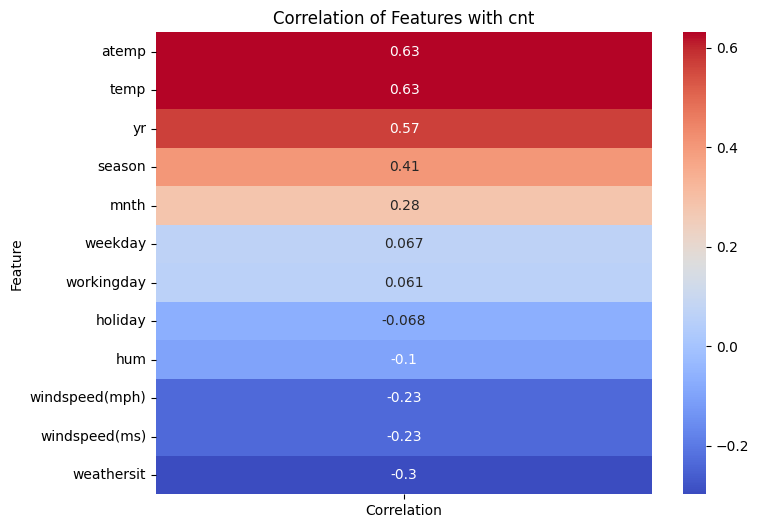

In [20]:
import seaborn as sns

plt.figure(figsize=(8, len(corr_df) * 0.5))
sns.heatmap(corr_df.set_index('Feature'), annot=True, cmap='coolwarm')
plt.title('Correlation of Features with cnt')
plt.show()

У вибірці є ознаки, що корелюють із цільовою, а отже, завдання можна розв'язувати лінійними методами.

За графіками видно, що деякі ознаки схожі між собою. Тому давайте також порахуємо кореляції між речовими ознаками.

## Завдання 3

Порахуйте попарні кореляції між ознаками temp, atemp, hum, windspeed(mph), windspeed(ms) і cnt
за допомогою методу corr:

In [25]:
features = ['temp', 'atemp', 'hum', 'windspeed(mph)', 'windspeed(ms)', 'cnt']
corr_df = df[features].corr()
print(corr_df)

                    temp     atemp       hum  windspeed(mph)  windspeed(ms)  \
temp            1.000000  0.991702  0.126963       -0.157944      -0.157944   
atemp           0.991702  1.000000  0.139988       -0.183643      -0.183643   
hum             0.126963  0.139988  1.000000       -0.248489      -0.248489   
windspeed(mph) -0.157944 -0.183643 -0.248489        1.000000       1.000000   
windspeed(ms)  -0.157944 -0.183643 -0.248489        1.000000       1.000000   
cnt             0.627494  0.631066 -0.100659       -0.234545      -0.234545   

                     cnt  
temp            0.627494  
atemp           0.631066  
hum            -0.100659  
windspeed(mph) -0.234545  
windspeed(ms)  -0.234545  
cnt             1.000000  


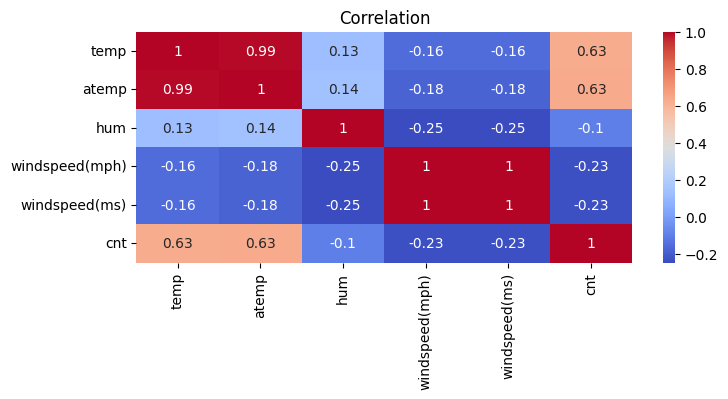

In [27]:
plt.figure(figsize=(8, len(corr_df) * 0.5))
sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.title('Correlation')
plt.show()

На діагоналях, як і належить, стоять одиниці. Однак у матриці є ще дві пари сильно корелюючих стовпців: temp і atemp (корелюють за своєю природою) і два windspeed (тому що це просто переведення одних одиниць в інші). Далі ми побачимо, що цей факт негативно позначається на навчанні лінійної моделі.

Насамкінець подивимося середні ознак (метод mean), щоб оцінити масштаб ознак і частки 1 у бінарних ознак.

## Завдання 4

Виведіть середні ознак.

In [28]:
df.mean()

,0
season,2.496580
yr,0.500684
mnth,6.519836
holiday,0.028728
weekday,2.997264
workingday,0.683995
weathersit,1.395349
temp,20.310776
atemp,23.717699
hum,62.789406


Ознаки мають різний масштаб, отже, для подальшої роботи нам краще нормувати матрицю об'єкти-ознаки.

### Проблема перша: колінеарні ознаки

Отже, у наших даних одна ознака дублює іншу, і є ще дві дуже схожі. Звичайно, ми могли б одразу видалити дублікати, але давайте подивимося, як відбувалося б навчання моделі, якби ми не помітили цю проблему.

Для початку проведемо масштабування, або стандартизацію ознак: з кожної ознаки віднімемо її середнє і поділимо на стандартне відхилення. Це можна зробити за допомогою методу scale.

Крім того, необхідно перемішати вибірку, це буде потрібно для крос-валідації.

In [29]:
from sklearn.preprocessing import scale
from sklearn.utils import shuffle

In [30]:
df_shuffled = shuffle(df, random_state=42)
X = scale(df_shuffled[df_shuffled.columns[:-1]])
y = df_shuffled["cnt"]

Давайте навчимо лінійну регресію на наших даних і подивимося на ваги ознак.

In [31]:
from sklearn.linear_model import LinearRegression

## Завдання 5

Створіть об'єкт лінійного регресора, навчіть його на всіх даних і виведіть ваги моделі (ваги зберігаються у змінній `coef_` класу регресора). Можна виводити пари (назва ознаки, вага), скориставшись функцією `zip`, вбудованою в мову python. Назви ознак зберігаються у змінній `df.columns`.


In [36]:
clf = LinearRegression()
clf.fit(X, y)
clf.score(X, y)

0.8005756472255201

In [35]:
pd.DataFrame(zip(df.columns, clf.coef_), columns=['Feature', 'Coefficient'])

,Feature,Coefficient
0,season,5.708638e+02
1,yr,1.021965e+03
2,mnth,-1.413017e+02
3,holiday,-8.675934e+01
4,weekday,1.372251e+02
5,workingday,5.639188e+01
6,weathersit,-3.302265e+02
7,temp,3.674837e+02
8,atemp,5.855494e+02
9,hum,-1.456143e+02


Ми бачимо, що ваги при лінійно-залежних ознаках за модулем значно більші, ніж при інших ознаках. Щоб зрозуміти, чому так сталося, згадаємо аналітичну формулу, за якою обчислюються ваги лінійної моделі в методі найменших квадратів:

$$w = (X^TX)^{-1} X^T y$$

Якщо в $X$ є колінеарні (лінійно-залежні) стовпці, матриця $X^TX$ стає виродженою, і формула перестає бути коректною. Чим більш залежні ознаки, тим менший визначник цієї матриці й тим гірша апроксимація $Xw \approx y$. Таку ситуацію називають _проблемою мультиколінеарності_.

З парою (temp, atemp) трохи менше корелюючих змінних такого не сталося, однак на практиці завжди варто уважно стежити за коефіцієнтами при схожих ознаках.

Для того щоб розв'язати проблему мультиколінеарності, потрібно скористатися регуляризатором. До оптимізуючого функціоналу додають $L_1$ або $L_2$ норму ваг, помножену на коефіцієнт регуляризації $\alpha$. У першому випадку метод називається Lasso, а у другому — Ridge.

### Завдання 6
Давайте спробуємо навчити лінійні моделі з $L_1$ і $L_2$-регуляризацією, а далі порівняємо їхні ваги. Навчіть регресори Ridge і Lasso з параметрами за замовчуванням і переконайтеся, що проблема з вагами вирішилась.

Навчіть лінійну модель з $L_1$-регуляризацією (клас Lasso) і виведіть ваги.

In [38]:
from sklearn.linear_model import Lasso

clf = Lasso().fit(X, y)

pd.DataFrame(zip(df.columns, clf.coef_), columns=['Feature', 'Coefficient'])

,Feature,Coefficient
0,season,5.602416e+02
1,yr,1.019463e+03
2,mnth,-1.287306e+02
3,holiday,-8.615278e+01
4,weekday,1.373479e+02
5,workingday,5.521237e+01
6,weathersit,-3.323699e+02
7,temp,3.763632e+02
8,atemp,5.765308e+02
9,hum,-1.441292e+02


Навчіть лінійну модель з $L_2$-регуляризацією (клас Ridge) і виведіть ваги.

In [39]:
from sklearn.linear_model import Ridge

clf = Ridge().fit(X, y)

pd.DataFrame(zip(df.columns, clf.coef_), columns=['Feature', 'Coefficient'])

,Feature,Coefficient
0,season,563.064572
1,yr,1018.948379
2,mnth,-131.873320
3,holiday,-86.746098
4,weekday,138.005111
5,workingday,55.903110
6,weathersit,-332.349788
7,temp,386.457889
8,atemp,566.347047
9,hum,-145.071327


### Завдання 7

На відміну від $L_2$-регуляризації, $L_1$ обнуляє ваги при деяких ознаках. Давайте поспостерігаємо, як змінюються ваги зі збільшенням коефіцієнта регуляризації $\alpha$.

Для кожного значення коефіцієнта з `alphas` навчіть регресор `Lasso` і запишіть ваги у список `coefs_lasso`, а потім навчіть `Ridge` і запишіть ваги у список`coefs_ridge`. Конвертуйте отримані списки в `np.array`.

In [54]:
alphas = np.arange(1, 500, 50)

coefs_lasso = np.zeros((len(alphas), len(df.columns) - 1))
coefs_ridge = np.zeros((len(alphas), len(df.columns) - 1))

for alpha in alphas:
    clf = Lasso(alpha=alpha).fit(X, y)
    coefs_lasso[alphas == alpha] = clf.coef_
    clf = Ridge(alpha=alpha).fit(X, y)
    coefs_ridge[alphas == alpha] = clf.coef_

coefs_lasso = np.array(coefs_lasso)
coefs_ridge = np.array(coefs_ridge)

Проаналізуйте динаміку ваг при збільшенні параметра регуляризації:

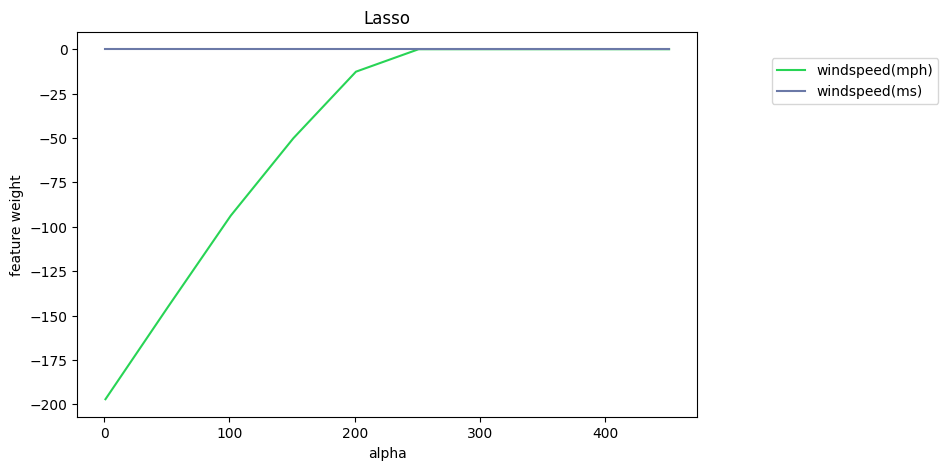

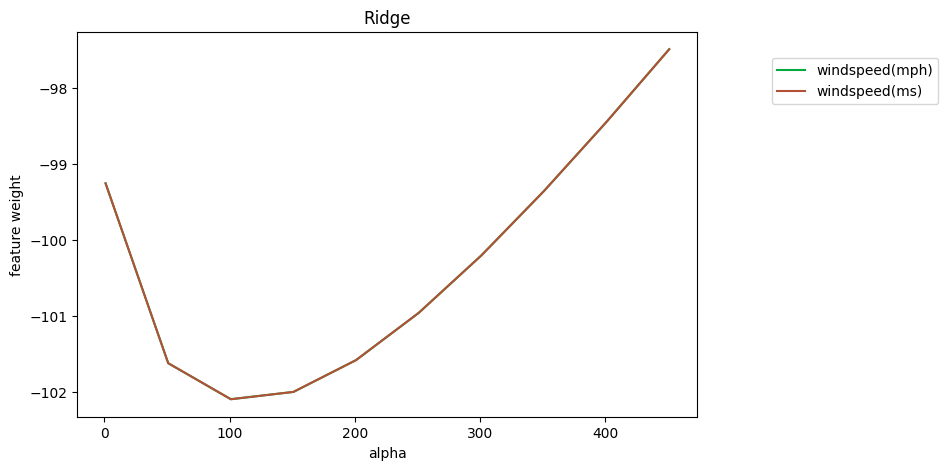

In [57]:
plt.figure(figsize=(8, 5))

for coef, feature in zip(coefs_lasso.T, df.columns):
    if feature == 'windspeed(mph)' or feature == "windspeed(ms)":
      plt.plot(alphas, coef, label=feature, color=np.random.rand(3))

plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Lasso")

plt.figure(figsize=(8, 5))
for coef, feature in zip(coefs_ridge.T, df.columns):
    if feature == 'windspeed(mph)' or feature == "windspeed(ms)":
      plt.plot(alphas, coef, label=feature, color=np.random.rand(3))

plt.legend(loc="upper right", bbox_to_anchor=(1.4, 0.95))
plt.xlabel("alpha")
plt.ylabel("feature weight")
plt.title("Ridge")

plt.show()

Проаналізуйте графіки та дайте відповіді на такі запитання.

1. Який регуляризатор (Ridge або Lasso) агресивніше зменшує ваги при одному й тому самому alpha? **Ridge**
1. Що станеться з вагами Lasso, якщо alpha зробити дуже великим? Поясніть, чому так відбувається. **Практично всі ваги стануть дуже ницькими і будуть прямувати до нуля**
1. Чи можна стверджувати, що `Lasso` виключає одну з ознак `windspeed` при будь-якому значенні `alpha > 0`? **Одна з ознак при будьякому alpha > 0 стала
 0 - тобто практично виключила одну ознаку, інша виключилася при  alpha > 250** А Ridge? **Для Ridge, обидві ознаки windspeed (mph) та windspeed (ms) мають від’ємні коефіцієнти, і з ростом alpha коефіцієнти лише поступово зменшуються, але не стають рівними нулю.** Вважається, що регуляризатор виключає ознаку, якщо коефіцієнт при ньому менший $10^{-3}$.
1. Який із регуляризаторів підійде для відбору неінформативних ознак? **найкраще підходить Lasso. Вона може встановлювати коефіцієнти неінформативних ознак точно в нуль, фактично виключаючи їх з моделі. Це дозволяє ідентифікувати та відсіяти ознаки, які не сприяють покращенню моделі.**

### Завдання 8

Далі будемо працювати з `Lasso`.

Отже, ми бачимо, що при зміні alpha модель по-різному підбирає коефіцієнти ознак. Нам потрібно вибрати найкраще alpha.

Для цього, по-перше, нам потрібна метрика якості. Будемо використовувати як метрику сам оптимізований функціонал методу найменших квадратів, тобто `Mean Square Error`.

По-друге, потрібно зрозуміти, на яких даних цю метрику рахувати. Не можна вибирати `alpha` за значенням MSE на навчальній вибірці, тому що тоді ми не зможемо оцінити, як модель буде робити передбачення на нових для неї даних. Якщо ми виберемо одне розбиття вибірки на навчальну та тестову (це називається holdout), то налаштуємося на конкретні "нові" дані, і знову можемо перенавчитися. Тому будемо робити декілька розбиттів вибірки, на кожному пробувати різні значення alpha, а потім усереднювати MSE. Найзручніше робити такі розбиття крос-валідацією, тобто розділити вибірку на $K$ частин, і кожного разу брати одну з них як тестову, а з блоків, що залишилися, складати навчальну вибірку.

Робити крос-валідацію для регресії в sklearn зовсім просто: для цього є спеціальний регресор, __LassoCV__, який бере на вхід список із alpha і для кожного з них обчислює MSE на крос-валідації. Після навчання (якщо залишити параметр cv=3 за замовчуванням) регресор буде містити змінну __mse\_path\___, матрицю розміру len(alpha) x k, k = 3 (число блоків у крос-валідації), що містить значення MSE на тесті для відповідних запусків. Крім того, у змінній alpha\_ буде зберігатися вибране значення параметра регуляризації, а в coef\_, традиційно, навчені ваги, що відповідають цьому alpha_.

Зверніть увагу, що регресор може змінювати порядок, у якому він проходить по alphas; для зіставлення з матрицею MSE краще використовувати змінну регресора alphas_.

Навчіть регресор `LassoCV` на всіх параметрах регуляризації з alpha. Побудуйте графік _усередненого_ за рядками `MSE` в залежності від `alpha` (використовуйте для цього функцію `create_plot`).

Виведіть вибране `alpha`, а також пари "ознака-коефіцієнт" для навченого вектора коефіцієнтів.

In [63]:
def create_plot(data, title, xlabel, ylabel, figsize=None):
    size = figsize or (15, 5)
    plt.figure(figsize=size)

    x = list(map(lambda e: e[0], data))
    y = list(map(lambda e: e[1], data))
    plt.plot(x, y)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.grid()
    plt.show()

6
           Feature   Coefficient
0           season  5.320190e+02
1               yr  1.015060e+03
2             mnth -1.000395e+02
3          holiday -8.329396e+01
4          weekday  1.325045e+02
5       workingday  5.155709e+01
6       weathersit -3.305599e+02
7             temp  3.706799e+02
8            atemp  5.813969e+02
9              hum -1.400074e+02
10  windspeed(mph) -1.917714e+02
11   windspeed(ms) -2.685470e-08


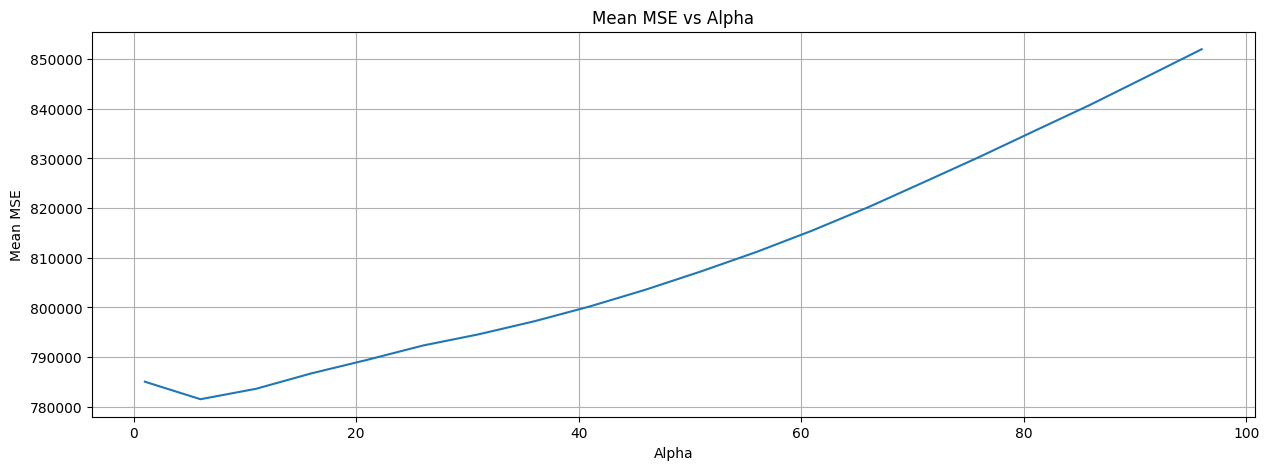

In [64]:
from sklearn.linear_model import LassoCV

alphas = np.arange(1, 100, 5)

regressor = LassoCV(alphas=alphas, cv=3)
regressor.fit(X, y)

print(regressor.alpha_)
print(pd.DataFrame(zip(df.columns, regressor.coef_), columns=['Feature', 'Coefficient']))

mean_mse = np.mean(regressor.mse_path_, axis=1)
mse_data = list(zip(regressor.alphas_, mean_mse))

create_plot(mse_data, 'Mean MSE vs Alpha', 'Alpha', 'Mean MSE')

Отже, ми вибрали певний параметр регуляризації. Давайте подивимося, які б ми вибирали alpha, якби ділили вибірку лише один раз на навчальну та тестову, тобто розглянемо траєкторії MSE, що відповідають окремим блокам вибірки.

### Завдання 9

Виведіть значення `alpha`, що відповідають мінімумам `MSE` на кожному розбитті (тобто за стовпцями).
На трьох окремих графіках візуалізуйте стовпці `mse_path_`.


In [69]:
n_splits = regressor.mse_path_.shape[1]

for split in range(n_splits):
    min_mse_idx = np.argmin(regressor.mse_path_[:, split])
    min_alpha = regressor.alphas_[min_mse_idx]
    min_mse = regressor.mse_path_[min_mse_idx, split]
    print(f"Розбиття {split + 1}: Мінімальне MSE = {min_mse} при alpha = {min_alpha}")

Розбиття 1: Мінімальне MSE = 733725.7604052249 при alpha = 6
Розбиття 2: Мінімальне MSE = 799433.1673691692 при alpha = 1
Розбиття 3: Мінімальне MSE = 796979.8955193626 при alpha = 51


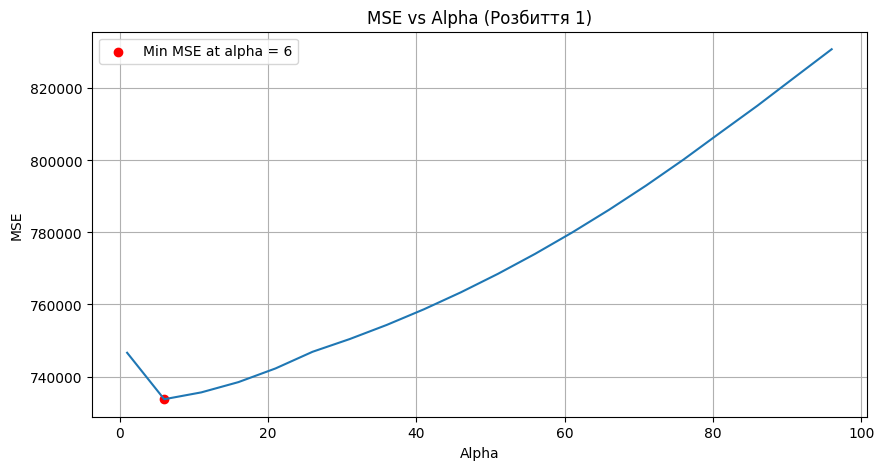

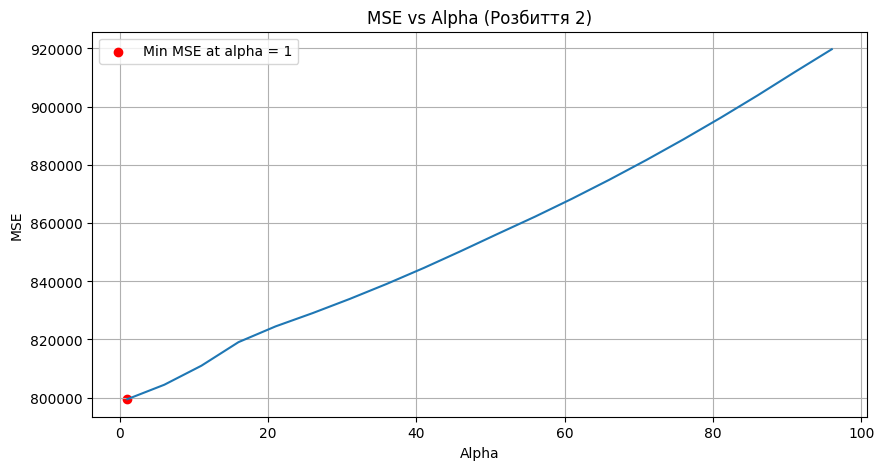

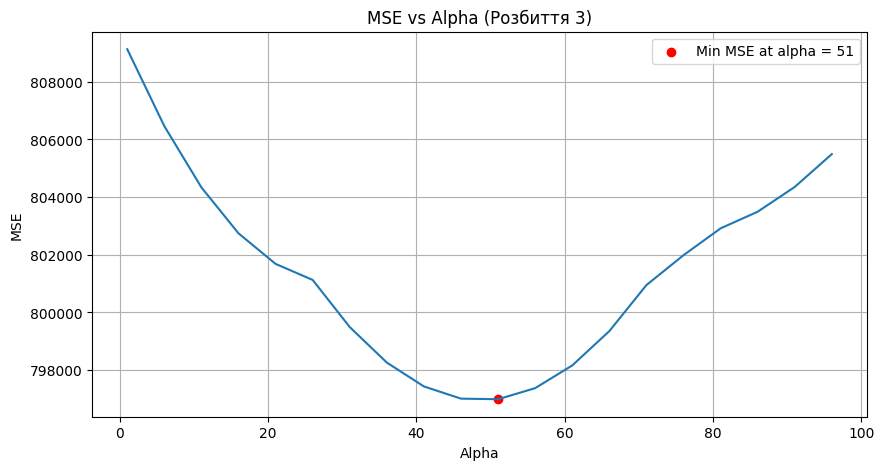

In [70]:
for split in range(n_splits):
    plt.figure(figsize=(10, 5))
    plt.plot(regressor.alphas_, regressor.mse_path_[:, split])

    min_mse_idx = np.argmin(regressor.mse_path_[:, split])
    min_alpha = regressor.alphas_[min_mse_idx]
    min_mse = regressor.mse_path_[min_mse_idx, split]

    plt.scatter(min_alpha, min_mse, color='red', label=f'Min MSE at alpha = {min_alpha}')
    plt.title(f"MSE vs Alpha (Розбиття {split + 1})")
    plt.xlabel("Alpha")
    plt.ylabel("MSE")
    plt.grid(True)
    plt.legend()
    plt.show()

На кожному розбитті оптимальне значення `alpha` своє, і йому відповідає велике MSE на інших розбиттях. Виходить, що ми налаштовуємося на конкретні навчальні та контрольні вибірки. При виборі `alpha` на крос-валідації ми вибираємо дещо "середнє", що даватиме прийнятне значення метрики на різних розбиттях вибірки.

### Завдання 10

Нарешті, як прийнято в аналізі даних, давайте проінтерпретуємо результат. Дайте відповіді на наступні запитання.

#### Запитання 1

В останній навченій моделі виберіть 4 ознаки з найбільшими (позитивними) коефіцієнтами (і випишіть їх), подивіться на візуалізації залежностей `cnt` від цих ознак, які ми зображали у блоці "Ознайомлення з даними". Чи видно зростаючу лінійну залежність `cnt` від цих ознак за графіками? Чи логічно стверджувати (виходячи зі здорового глузду), що чим більше значення цих ознак, тим більше людей захочуть взяти велосипеди?

__Відповідь:__

In [77]:
coefficients_df = pd.DataFrame({
    'Feature': df.columns[:-1],
    'Coefficient': regressor.coef_
})

top_positive_coeffs = coefficients_df[coefficients_df['Coefficient'] > 0].nlargest(4, 'Coefficient')
print("Ознаки з найбільшими позитивними коефіцієнтами:")
print(top_positive_coeffs)

Ознаки з найбільшими позитивними коефіцієнтами:
  Feature  Coefficient
1      yr  1015.060223
8   atemp   581.396931
0  season   532.018983
7    temp   370.679855


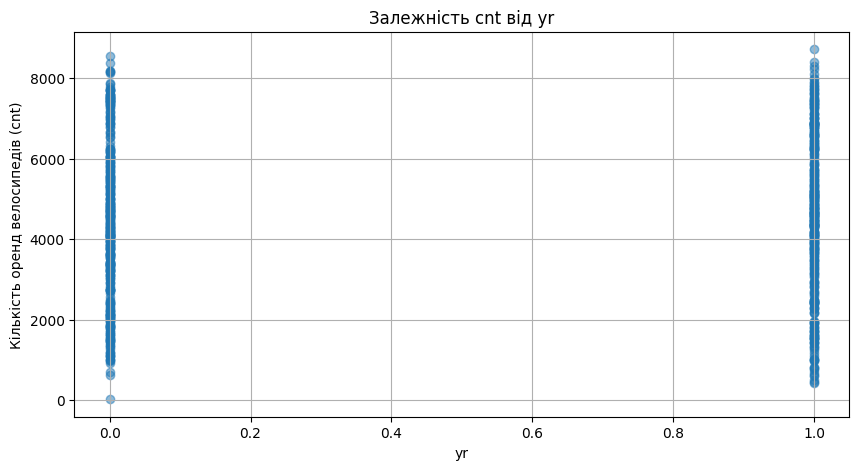

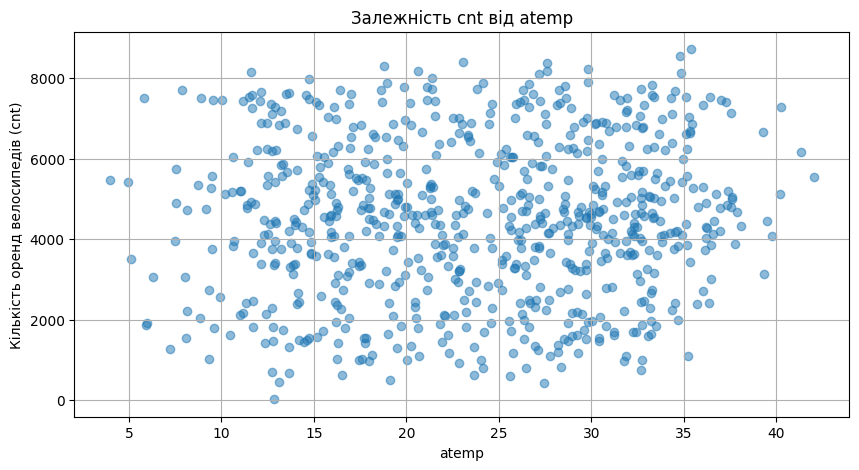

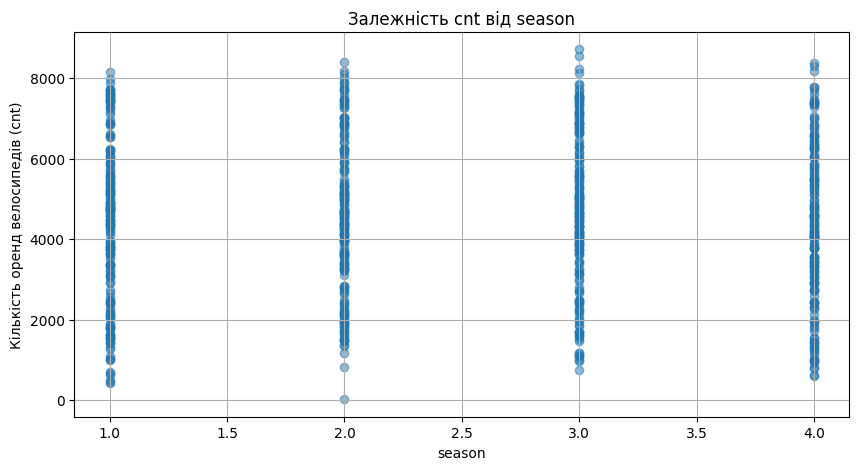

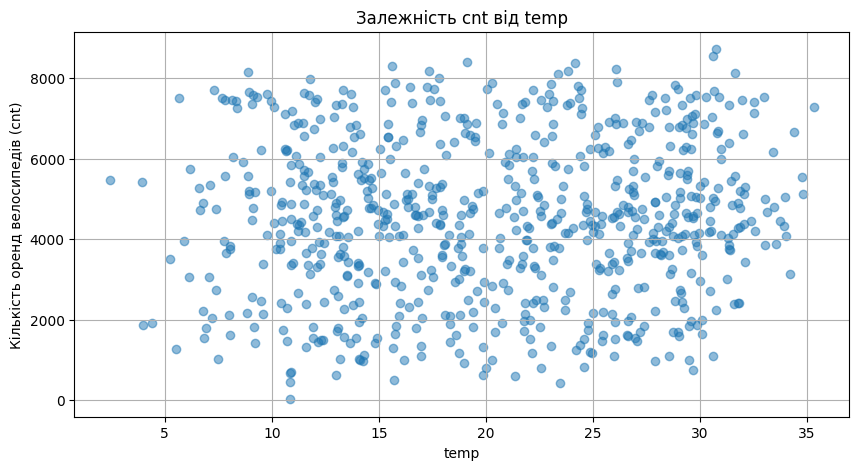

In [79]:
for feature in top_positive_coeffs['Feature']:
    plt.figure(figsize=(10, 5))
    plt.scatter(df[feature], y, alpha=0.5)
    plt.title(f"Залежність cnt від {feature}")
    plt.xlabel(feature)
    plt.ylabel("Кількість оренд велосипедів (cnt)")
    plt.grid(True)
    plt.show()

**Виходячи з здорового глузду, якщо ці ознаки (наприклад, температура, число вихідних днів, рівень сонячного освітлення) мають прямий зв’язок із комфортом або зручністю використання велосипедів, то можна зробити висновок, що чим більше значення цих ознак, тим більше людей захочуть орендувати велосипеди.**

Для кожної ознаки буде своя логіка:
  - Температура: Логічно, що в комфортну погоду більше людей братимуть велосипеди.
  - Сонячне освітлення: У сонячні дні велосипедна активність також може бути вищою.
  - Інші ознаки: Аналіз залежатиме від конкретних значень обраних ознак.

#### Запитання 2

Виберіть 3 ознаки з найбільшими за модулем негативними коефіцієнтами (і випишіть їх), подивіться на відповідні візуалізації. Чи видно лінійну залежність, що зменшується? Чи логічно стверджувати, що чим більша величина цих ознак, тим менше людей захочуть взяти велосипеди?

__Відповідь:__

In [80]:
top_negative_coeffs = coefficients_df[coefficients_df['Coefficient'] < 0].nsmallest(3, 'Coefficient')
print("Ознаки з найбільшими за модулем негативними коефіцієнтами:")
print(top_negative_coeffs)

Ознаки з найбільшими за модулем негативними коефіцієнтами:
           Feature  Coefficient
6       weathersit  -330.559857
10  windspeed(mph)  -191.771408
9              hum  -140.007406


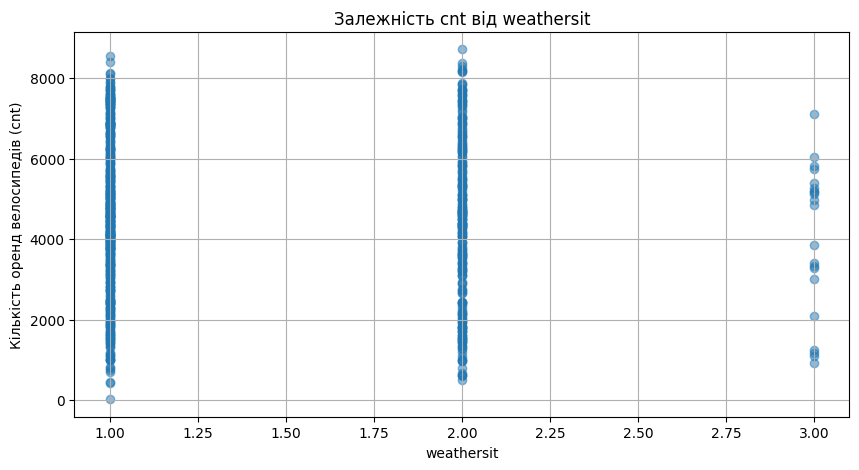

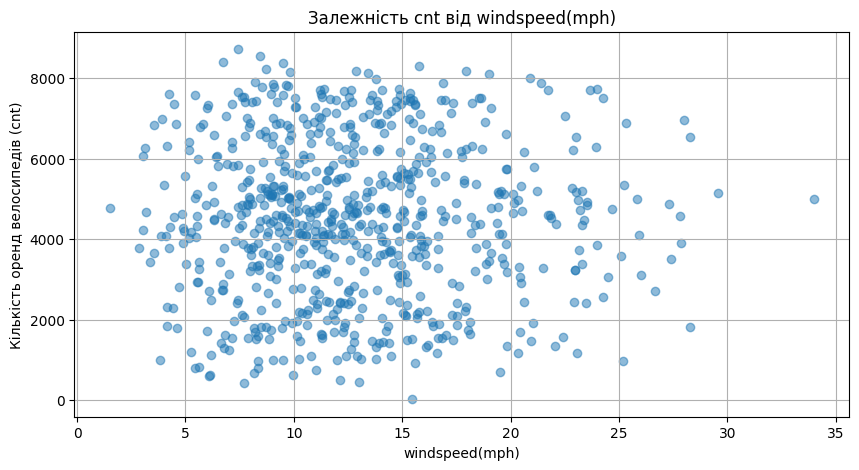

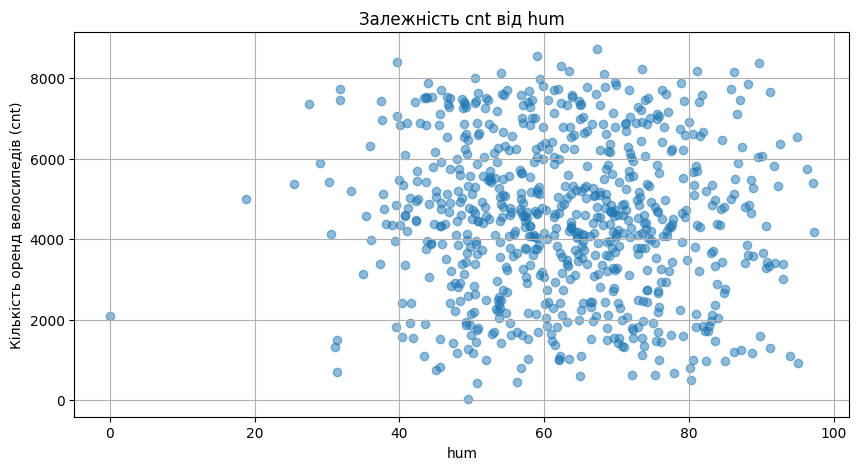

In [81]:
for feature in top_negative_coeffs['Feature']:
    plt.figure(figsize=(10, 5))
    plt.scatter(df[feature], y, alpha=0.5)
    plt.title(f"Залежність cnt від {feature}")
    plt.xlabel(feature)
    plt.ylabel("Кількість оренд велосипедів (cnt)")
    plt.grid(True)
    plt.show()

#### Запитання 3

Випишіть ознаки з коефіцієнтами, близькими до нуля (< 1e-3). Як ви думаєте, чому модель виключила їх із моделі (знову подивіться на графіки)? Чи правда, що вони ніяк не впливають на попит на велосипеди?

__Відповідь:__

In [82]:
excluded_features = coefficients_df[np.abs(coefficients_df['Coefficient']) < 1e-3]

print("Ознаки з коефіцієнтами, близькими до нуля:")
print(excluded_features)

Ознаки з коефіцієнтами, близькими до нуля:
          Feature   Coefficient
11  windspeed(ms) -2.685470e-08


**Виключена ознака windspeed(ms) є сильно корельованими з windspeed(mph), Lasso могло виключити одну з них, щоб уникнути проблем із мультиколінеарністю. Це означає, що виключена ознака є неінформативними, оскільки їхня інформація дублюється іншими ознаками.**

### Висновок
Отже, ми подивилися, як можна стежити за адекватністю лінійної моделі, як відбирати ознаки і як грамотно, за можливості не налаштовуючись на якусь конкретну порцію даних, підбирати коефіцієнт регуляризації.

Варто зазначити, що за допомогою крос-валідації зручно підбирати лише невелику кількість параметрів. (1, 2, максимум 3), тому що для кожної допустимої їх комбінації нам доводиться декілька разів навчати модель. Такий процес займає багато часу, особливо якщо треба навчатися на великих обсягах даних.